In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [21]:
diff_exp_table = pd.read_csv("../results/deseq2_rsem/hydra_all_counts.tsv", sep="\t")

In [22]:
diff_exp_table.head()

,gene_id,transcript_id.s.,length,I25727-L1_effective_length,I25727-L1_expected_count,I25727-L1_TPM,I25727-L1_FPKM,I25728-L1_effective_length,I25728-L1_expected_count,I25728-L1_TPM,...,E05882_TPM,E05882_FPKM,E05883_effective_length,E05883_expected_count,E05883_TPM,E05883_FPKM,E05884_effective_length,E05884_expected_count,E05884_TPM,E05884_FPKM
0,HVAEP1.G000001,HVAEP1.T000001.1,920.00,715.92,0.00,0.00,0.00,713.55,0.00,0.00,...,0.00,0.00,721.06,0.00,0.00,0.00,721.63,0.0,0.00,0.00
1,HVAEP1.G000002,HVAEP1.T000002.1,4304.00,4099.91,321.39,3.85,3.47,4097.55,277.09,3.38,...,8.41,6.19,4105.06,122.51,9.33,6.99,4105.63,96.6,8.36,6.04
2,HVAEP1.G000003,HVAEP1.T000003.1,285.00,94.73,0.00,0.00,0.00,93.80,0.00,0.00,...,0.00,0.00,94.87,0.00,0.00,0.00,95.01,0.0,0.00,0.00
3,HVAEP1.G000004,"HVAEP1.T000004.1,HVAEP1.T000004.2,HVAEP1.T0000...",1119.33,915.29,0.00,0.00,0.00,457.69,1.00,0.11,...,0.00,0.00,920.41,0.00,0.00,0.00,920.98,0.0,0.00,0.00
4,HVAEP1.G000005,HVAEP1.T000005.1,207.00,37.60,0.00,0.00,0.00,37.35,0.00,0.00,...,0.00,0.00,34.34,0.00,0.00,0.00,33.78,0.0,0.00,0.00


In [3]:
sample_description = pd.read_csv("../data/rsem_counts/sample_descriptions.csv")
sample_description.head()

,EXP,ID,sample,treatment,batch
0,HydraAHL,I27651-S1,3OC12_1,3OC12,1
1,HydraAHL,I27652-S1,3OC12_2,3OC12,1
2,HydraAHL,I27653-S1,3OC12_3,3OC12,1
3,HydraAHL,I27654-S1,3OC12_4,3OC12,1
4,HydraAHL,I27655-S1,3OC12_5,3OC12,1


In [4]:
samples = sample_description["ID"].apply(lambda x: x+"_TPM")

In [5]:
annotation_table = pd.read_csv("../data/annotation_KO_GO.csv")

In [6]:
annotation_table.head()

,ID,KO,KO_definition,Score,Second.best,Score2,UniProtKB,KEGG.ID,KO.Number,GO.terms
0,HVAEP1.T000001.1,NaN,NaN,6.0,K21595,1.0,NaN,NaN,NaN,NaN
1,HVAEP1.T000002.1,K07188,"LIPE, HSL; hormone-sensitive lipase [EC:3.1.1.79]",171.0,NaN,NaN,P54310,LIPS_MOUSE,mmu:16890;,caveola [GO:0005901]; cytoplasm [GO:0005737]; ...
2,HVAEP1.T000003.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HVAEP1.T000004.1,NaN,NaN,8.0,K10251,1.0,NaN,NaN,NaN,NaN
4,HVAEP1.T000004.2,NaN,NaN,9.0,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
wnt_genes_portal = ["HVAEP1_T001980", "HVAEP1_T001985", "HVAEP1_T003934", "HVAEP1_T005251", "HVAEP1_T009462", "HVAEP1_T010730", 
             "HVAEP1_T010776", "HVAEP1_T010792", "HVAEP1_T011290", "HVAEP1_T011553", "HVAEP1_T011641", "HVAEP1_T013231",
             "HVAEP1_T016743", "HVAEP1_T021814", "HVAEP1_T021819", "HVAEP1_T021820", "HVAEP1_T022460", "HVAEP1_T022678",
             "HVAEP1_T023071", "HVAEP1_T023618", "HVAEP1_T023882", "HVAEP1_T028556"]
wnt_genes = []
for wnt in wnt_genes_portal:
    wnt = wnt.split("_")[1].replace("T","G")
    wnt_genes.append(wnt)

In [7]:
go_annot = annotation_table[annotation_table["GO.terms"].isna() == False]
go_annot["gene_id"] = go_annot["ID"].apply(lambda x: x.split(".")[1].replace("T","G"))

wnt_genes = go_annot[go_annot["GO.terms"].str.contains("wnt")]
frizzled_genes = go_annot[go_annot["GO.terms"].str.contains("frizzled")]

/blast/miniconda3/lib/python3.8/site-packages/pandas/core/frame.py:3607: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._set_item(key, value)


In [8]:
len(frizzled_genes)

17

In [24]:
columns_to_extract = ["gene_id"]
for col in diff_exp_table.columns:
    if "TPM" in col:
        columns_to_extract.append(col)
tpm_table = diff_exp_table[columns_to_extract]
tpm_table["gene_id"] = tpm_table["gene_id"].apply(lambda x: x.split(".")[1])
tpm_table.head()

/blast/miniconda3/lib/python3.8/site-packages/pandas/core/frame.py:3607: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._set_item(key, value)


,gene_id,I25727-L1_TPM,I25728-L1_TPM,I25729-L1_TPM,I25730-L1_TPM,I25731-L1_TPM,I25732-L1_TPM,I25733-L1_TPM,I25734-L1_TPM,I25735-L1_TPM,...,E05875_TPM,E05876_TPM,E05877_TPM,E05878_TPM,E05879_TPM,E05880_TPM,E05881_TPM,E05882_TPM,E05883_TPM,E05884_TPM
0,G000001,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,G000002,3.85,3.38,0.02,0.04,2.53,2.50,2.42,0.02,0.0,...,8.15,9.86,10.29,9.09,9.14,8.37,9.63,8.41,9.33,8.36
2,G000003,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,G000004,0.00,0.11,0.00,0.04,0.00,0.12,0.00,0.00,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,G000005,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [10]:
wnt_genes_to_tpm = wnt_genes.merge(tpm_table, on="gene_id")[columns_to_extract[1:]]
frizzled_genes_to_tpm = frizzled_genes.merge(tpm_table, on="gene_id")[columns_to_extract[1:]]

In [25]:
wnt_genes_to_tpm = tpm_table[tpm_table["gene_id"].isin(wnt_genes)]


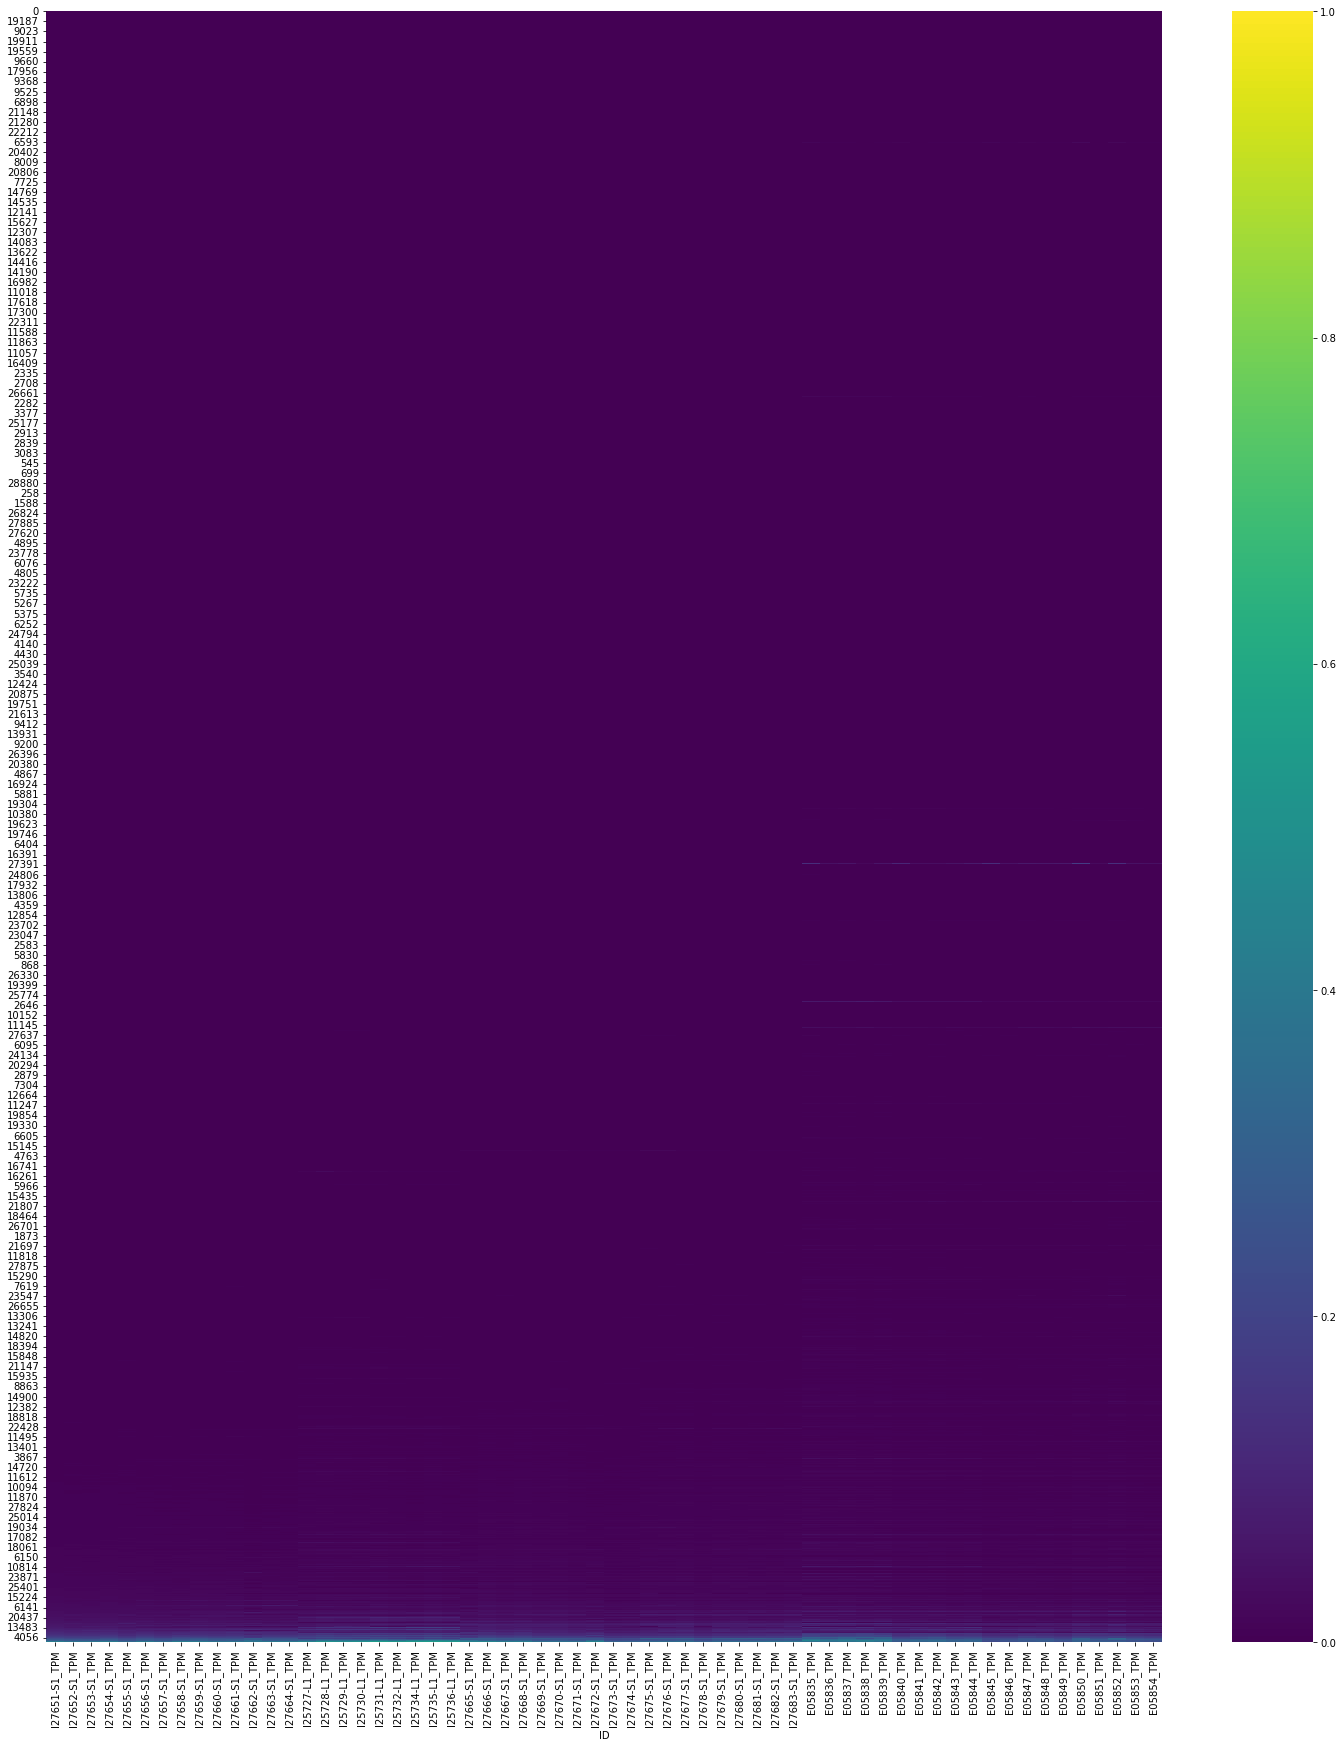

In [18]:
plt.figure(figsize=(25,30))
#tpm_table[samples]
sns.heatmap(wnt_genes_to_tpm.sort_values(by=samples[0]), annot=False, cmap="viridis", xticklabels=samples)
plt.savefig("../results/test2.jpg", dpi=400)

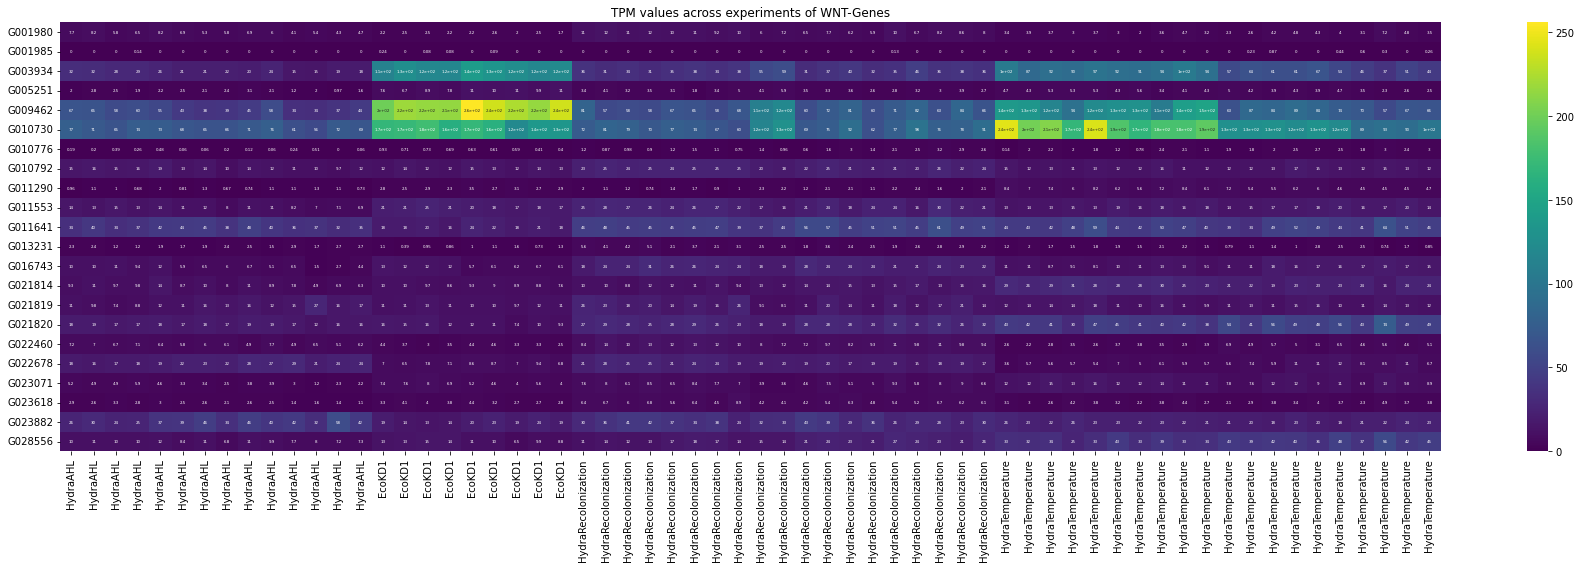

In [40]:
plt.figure(figsize=(25, 8))
custom_y_labels = wnt_genes
sns.heatmap(wnt_genes_to_tpm[samples], annot=True, cmap='viridis', annot_kws={"fontsize":4}, yticklabels=custom_y_labels, xticklabels=experiment)
#plt.xlabel('X Values')
#plt.ylabel('Categories')
plt.title('TPM values across experiments of WNT-Genes')
#plt.show()
plt.tight_layout()
plt.savefig("../results/figures/genes_tpm_heatmaps/wnt_tpm_heatmap.jpg")

In [ ]:
plt.figure(figsize=(25, 8))
sns.heatmap(frizzled_genes_to_tpm[samples], annot=True, cmap='viridis', annot_kws={"fontsize":4})
#plt.xlabel('X Values')
#plt.ylabel('Categories')
#plt.title('Heatmap of X Values by Categories')
plt.show()

In [32]:
sample_names = [sample.split("_")[0] for sample in samples]

In [38]:
experiment = sample_description[sample_description["ID"].isin(sample_names) ]["EXP"]